## Use 3D decon for 2D images


Load the images and assign the wavelengths

In [5]:
from skimage.io import imread
from tnia.plotting.plt_helper import imshow2d
import numpy as np

im_path = r"/home/bnorthan/images/tnia-python-images/deconvolution/c.elegans/"

im_names = ['CElegans-CY3.tif', 'CElegans-DAPI.tif', 'CElegans-FITC.tif']

images = []
for im_name in im_names:
    image = imread(im_path + im_name)
    images.append(image)

print(type(images[0]), print(images[0].shape), print(images[0].dtype), print(images[0].min()), print(images[0].max()))

waves = ['Cy3', 'DAPI', 'FITC']
wavelengths = [0.550, 0.360, 0.488]  # excitation wavelengths in µm

xy_spacing = 0.0645
z_spacing = 0.160


(104, 712, 672)
uint16
215
2842
<class 'numpy.ndarray'> None None None None


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


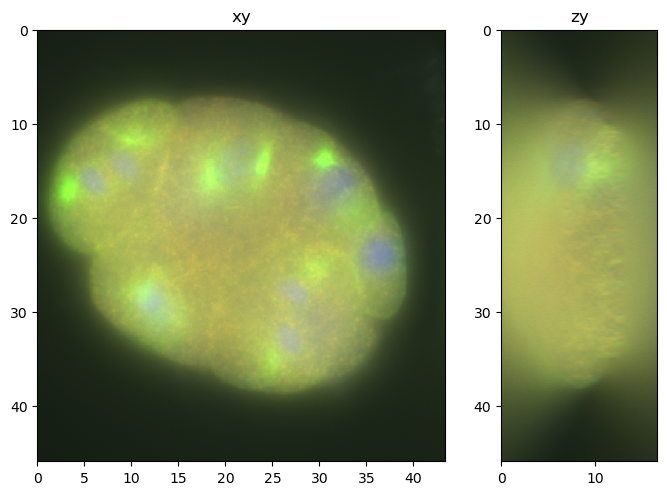

In [6]:
from tnia.plotting.plt_helper import color_dictionary, create_rgb, imshow_multi2d, create_linear_napari_color_map
from tnia.plotting.projections import show_xy_zy_slice_center
import matplotlib.pyplot as plt

color_image = create_rgb(images, waves, color_dictionary)

fig = show_xy_zy_slice_center(color_image, figsize=(8,8),sxy=xy_spacing, sz=z_spacing)

## Generate a PSF

Cy3 (550 nm)  shape: (65, 65, 65)
DAPI (360 nm)  shape: (65, 65, 65)
FITC (488 nm)  shape: (65, 65, 65)


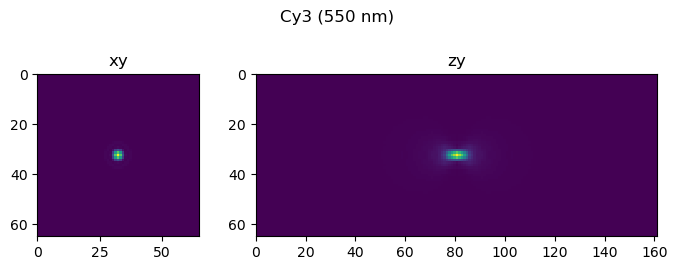

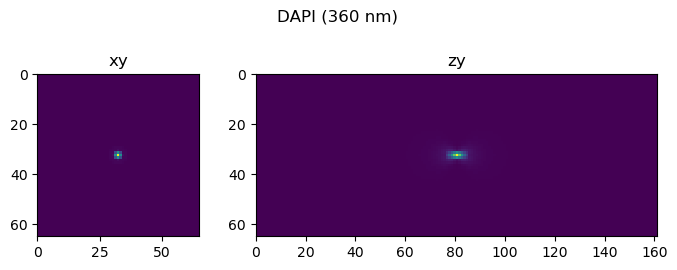

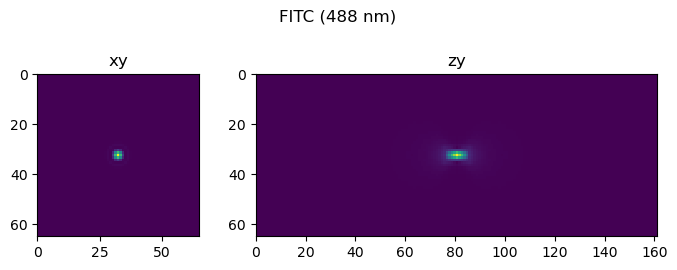

In [7]:
from tnia.deconvolution.psfs import gibson_lanni_3D
from tnia.plotting.projections import show_xy_zy_slice_center
import numpy as np
import matplotlib.pyplot as plt

xy_psf_dim = 65
NA = 1.5
x_voxel_size = 0.0645
z_voxel_size = 0.160
z_psf_dim = 65 
ni = 1.51
ns = 1.4
defocus = 0

psfs = []
for wave, wl in zip(waves, wavelengths):
    psf = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wl, use_psfm=True)
    psf = np.squeeze(psf.astype('float32'))
    psfs.append(psf)
    print(f'{wave} ({wl*1000:.0f} nm)  shape: {psf.shape}')

for psf, wave, wl in zip(psfs, waves, wavelengths):
    fig = show_xy_zy_slice_center(psf, sz=z_voxel_size/x_voxel_size, figsize=(8, 3))
    fig.suptitle(f'{wave} ({wl*1000:.0f} nm)', fontsize=12, y=0.98)
    fig.subplots_adjust(top=0.88)
    plt.show()

## Deconvolve the image using circulant and non-circulant 

Do decon twice because still fiddling with the API, and second time getting the 3D reconstruction back. 

In [4]:
# add trivial dimension to image
for i in range(len(images)):
    images[i] = images[i][None, ...]
    print(images[i].shape)

(1, 104, 712, 672)
(1, 104, 712, 672)
(1, 104, 712, 672)


In [8]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp
from tnia.deconvolution.decon_helper import create_saturation_mask

import timeit

num_iterations = 50

decons = []

for image, psf, wave in zip(images, psfs, waves):

    start = timeit.default_timer()    
    decon = richardson_lucy_cp(image, psf, num_iterations, noncirc=True)
    total = timeit.default_timer() - start
    decons.append(decon)
    print(f'{wave}: total time RL CP {total:.2f}s')


Input size: (104, 712, 672), PSF size: (65, 65, 65)

0 

OutOfMemoryError: Out of memory allocating 790,272,000 bytes (allocated so far: 7,507,584,000 bytes).

Take a look at 3d slice projections (even though we are deconvolving a 3D image, we are reconstructing in a 3d space)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


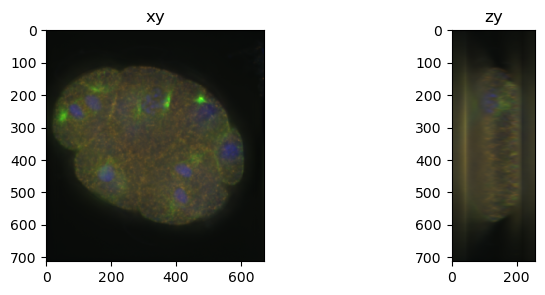

In [9]:
color_decon = create_rgb(decons, waves, color_dictionary)
fig = show_xy_zy_slice_center(color_decon, sz=z_voxel_size/x_voxel_size, figsize=(8, 3))